<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">סיכום והצגת תוצאות ביניים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">על מנת שנוכל לבחון את טיב הפתרון שמסתמך על OCR + REGEX נחשב עבורו את המדדים הנפוצים בתחום מדעי הנתונים כמו דיוק ,F1 ועוד</div>
</div>

In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">תוצאות השלבים הקודמים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כדי לחשב את המדדים הנדרשים                           נשתמש בתוצאות השלב הקודם טבלת התוצאות(passport_detection_results.csv) מכילה לכל תמונת קלט את הREGEX שנתפס עבורה ואת אחת משלות התוצאות הסופיות האפשריות עבור זיהוי הדרכון. בנוסף יצרנו ידנית טבלת תיוגים(passport_page_labels.csv)                                                                                              שמציינת לכל מסמך את העמוד שבו נמצא אצלו תצלום הדרכון ואת רמת הקושי שלו.</div>
</div>

In [2]:
RESULTS_FILE = "./passport_detection_results.csv"
LABELS_FILE = "./passport_page_labels.csv"

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">מיזוג והתאמת התוצאות לתצוגה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כדני שנוכל להשוות בין הגישה                            המחמירה יותר שכוללת רק תוצאות YES לבין המחמירה פחות שכוללת גם את הדפים                                     שכיבלו MAYBE נמזג את שתי הטבלאות ונוסיף עמודות מתאימות כדי                                              שנוכל להציג את שני המיקרים.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">העמודות שהוספנו</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">prediction_strict - עבור העמודים שבוודאות מכילים דרכון(YES)

prediction_permissive - עבור כלל העמודים שישסיכוי שזוהה בהם דרכון(YES+MAYBE)</div>
</div>

In [3]:
results_df = pd.read_csv(RESULTS_FILE, encoding="utf-8-sig")
labels_df = pd.read_csv(LABELS_FILE, encoding="utf-8-sig")

page_data_df = results_df["image_name"].str.extract(
    r"^(?P<document_id>.+)_page_(?P<page_number>\d+)\.(?:jpg|jpeg|png)$",
    flags=re.IGNORECASE,
)

page_data_df["page_number"] = page_data_df["page_number"].astype(int)

evaluation_df = pd.concat(
    [results_df, page_data_df],
    axis=1,
).merge(
    labels_df[["document_id", "passport_page_number"]],
    on="document_id",
)

evaluation_df["is_passport"] = (
    evaluation_df["page_number"]
    == evaluation_df["passport_page_number"]
).astype(int)

evaluation_df["prediction_strict"] = (
    evaluation_df["verdict"] == "YES"
).astype(int)

evaluation_df["prediction_permissive"] = (
    evaluation_df["verdict"].isin(["YES", "MAYBE"])
).astype(int)

evaluation_df.head()

,image_name,matched_pattern_names,verdict,document_id,page_number,passport_page_number,is_passport,prediction_strict,prediction_permissive
0,PDF_Edge_Case_11_page_1.jpg,NaN,NO,PDF_Edge_Case_11,1,1,1,0,0
1,PDF_Edge_Case_12_page_1.jpg,NaN,NO,PDF_Edge_Case_12,1,3,0,0,0
2,PDF_Edge_Case_12_page_2.jpg,NaN,NO,PDF_Edge_Case_12,2,3,0,0,0
3,PDF_Edge_Case_12_page_3.jpg,NaN,NO,PDF_Edge_Case_12,3,3,1,0,0
4,PDF_Edge_Case_12_page_4.jpg,NaN,NO,PDF_Edge_Case_12,4,3,0,0,0


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">חישוב מדדים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">המדדים Accuracy, Precision, Recall ו־F1 נבחרו כדי להעריך את הגישה הראשונית שבה בחרנו מכמה היבטים משלימים: Accuracy מודד את שיעור העמודים שסווגו נכון מתוך כלל העמודים, Precision בודק כמה מהעמודים שסומנו כדרכון הם באמת עמודי דרכון, Recall מודד כמה מעמודי הדרכון האמיתיים המערכת הצליחה לזהות, ו־F1 מספק מדד מאוזן המשלב בין Precision ל־Recall מדד זה יהיה גבוה כאשר נזהה גם חלק גדול מהעמודים שמכילים דרכון וגם נמנע מזיהוי שגוי של עמודים שאינם מכילים דרכון.  השימוש בכל ארבעת המדדים חשוב במיוחד משום שמספר העמודים הרגילים גדול ממספר עמודי הדרכון, ולכן הסתמכות על Accuracy בלבד עלולה להציג תמונה מטעה.</div>
</div>

In [4]:
def calculate_metrics(prediction_column, approach):
    y_true = evaluation_df["is_passport"]
    y_pred = evaluation_df[prediction_column]

    return {
        "approach": approach,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


metrics_df = pd.DataFrame([
    calculate_metrics("prediction_strict", "YES only"),
    calculate_metrics("prediction_permissive", "YES + MAYBE"),
])

metrics_df

,approach,accuracy,precision,recall,f1
0,YES only,0.794326,1.000000,0.064516,0.121212
1,YES + MAYBE,0.843972,0.846154,0.354839,0.500000


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">יצוג התפלגות הזיהויים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">בחרנו להשתמש במטריצת בילבול על מנת להציג את כמות ההצלחה בזיהוי הן דפים שמכילים דרכון והן דפים שאינם מכילים אותו, נציין שלא הוספנו נתוני טקסט שיכולים לגרום לזיהוי                                                                                                           שגוי                                                                                                             כמו מחרוזות עם המילה PASSPORT וכו על מנת שנוכל לקבל תחושה עד כמה בכלל אפשר לסמוך על שיטת הזיהוי שאיתה התחלנו.                                                                               </div>
</div>

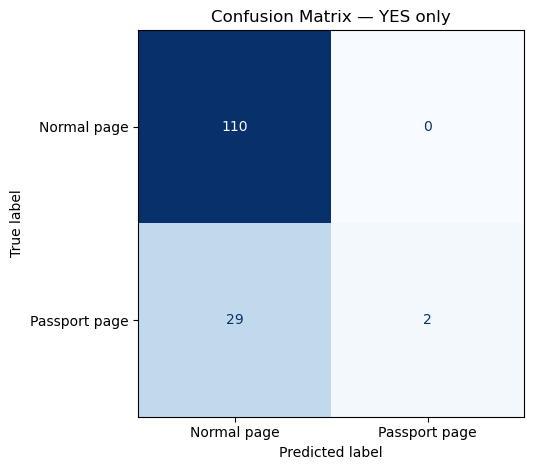

In [5]:
matrix = confusion_matrix(
    evaluation_df["is_passport"],
    evaluation_df["prediction_strict"],
)

ConfusionMatrixDisplay(
    matrix,
    display_labels=["Normal page", "Passport page"],
).plot(cmap="Blues", colorbar=False)

plt.title("Confusion Matrix — YES only")
plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">ממצאים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">רק 2 מתוך 31 עמודי הדרכון זוהו בוודאות. עם זאת, אף עמוד שאינו מכיל דרכון לא סווג בטעות כדרכון כלומר כל הזיהויים שהתקבלו היו נכונים.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-top: 10px;">היעדר סיווגי שווא מלמד שמנוע ה-OCR אינו מייצר טקסט שאינו קיים בתמונה. מכאן שהכשל אינו בקריאה שגויה אלא בכך שהטקסט אינו נקרא כלל, או נקרא באופן חלקי שאינו מספיק להתאמה לתבניות.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">OCR + Regex evaluation metrics</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">השוואה בין גישה מחמירה למתירנית</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כדי להבין לעומק את הפער בין שתי הגישות ביצענו השוואה                                                     גרפית בין המדדים שחישבנו קודם עבור שתיהן.</div>
</div>

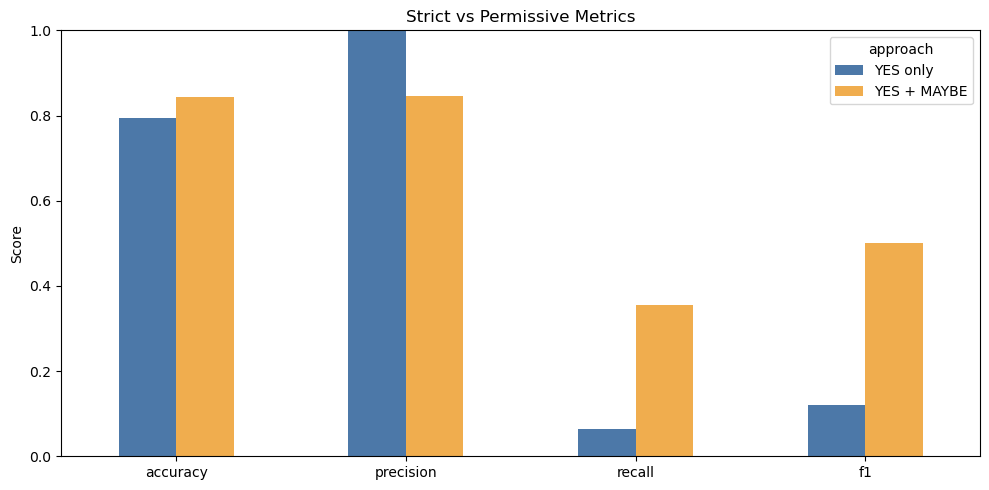

In [6]:
metrics_df.set_index("approach")[[
    "accuracy",
    "precision",
    "recall",
    "f1",
]].T.plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    color=["#4c78a8", "#f0ad4e"],
)
plt.title("Strict vs Permissive Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">ממצאים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">בגישה המחמירה כל זיהוי שהתקבל היה נכון, אבל רוב עמודי הדרכון פוספסו. כשמכלילים גם תוצאות MAYBE, ה-Recall עולה לכ-40% וה-Precision נשאר מעל 80% אך עדיין 20 מתוך 31 עמודי דרכון אינם מזוהים.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-top: 10px;">המערכת מדויקת כשהיא מזהה, אך מזהה מעט מדי. ריכוך נוסף של התבניות לא יפתור זאת הטקסט שסביב הדרכון עלול להכיל מחרוזות דומות, ותבניות מתירניות יגררו זיהויי שווא. לכן נעבור למודל זיהוי חזותי, שאינו תלוי בקריאת הטקסט.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px;">
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">מעבר לגישה מבוססת למידה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">מהשלב הראשון עולה שהגישה שנבחרה נתונה בין שני קצוות: תבניות מחמירות מפספסות את רוב עמודי הדרכון, ותבניות מתירניות עלולות להיתפס לטקסט אקראי המכיל מחרוזות דומות. שני הקצוות נובעים מאותו מקור  הזיהוי מסתמך על טקסט בלבד, ולטקסט אין הקשר מרחבי.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">רשת עצבית קונבולוציונית (CNN) פועלת אחרת. היא מזהה תבניות חזותיות בתמונה  קצוות, מרקמים ואזורים בעלי מבנה אופייני  ומצרפת אותן לייצוג של התמונה כולה. המאפיינים נלמדים מדוגמאות מתויגות ואינם מוגדרים מראש ככללים. בהקשר שלנו הרשת לומדת כיצד נראה תצלום דרכון בתוך מסמך, ואינה קוראת את הטקסט שבו ולכן טקסט אקראי הדומה למחרוזת שאנו מחפשים אינו מטעה אותה.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">לאחר אימון הרשת נבצע הדגמה על מסמך המכיל דרכון בעמוד מסוים, ובאמצעות OCR וביטויים רגולריים נחלץ ממנו את פרטי הדרכון.</div>
</div>